#**=====UAS PENAMBANGAN DATA=====**

####Nama     : Yankhairunisa Zahra Wiratania Putri
####NIM       : A11.2022.14328
####Kelompok : A11.4517
---

####**JUDUL**
#####Analisis Faktor-Faktor yang Mempengaruhi Kinerja Akademik Mahasiswa Menggunakan Decision Tree Classifier

####**RINGKASAN PROYEK**
A. Permasalahan
#####Studi kasus ini memiliki masalah kinerja akademik mahasiswa yang dipengaruhi oleh berbagai faktor, baik yang berhubungan dengan latar belakang pribadi maupun lingkungan belajar. Masalah pada faktor internal pada mahasiswa memiliki kondisi dan faktor unik yang bisa berbeda satu sama lain. Institusi pendidikan memerlukan model yang mampu memprediksi performa mahasiswa secara akurat, sehingga dapat mengidentifikasi mahasiswa yang mungkin memerlukan dukungan tambahan.
B. Tujuan
#####Menggunakan model Decision Tree bertujuan untuk menemukan faktor utama yang mempengaruhi kinerja akademik mahasiswa dan membangun model prediktif yang akurat. Hasil akhir yang diinginkan adalah model yang tidak hanya akurat dalam prediksi tetapi juga memberikan wawasan bagi institusi tentang faktor-faktor yang dapat diintervensi untuk meningkatkan performa akademik mahasiswa.
C. Alur penyelesaian
1.   Persiapan Data (Import dataset, Prepocessing data)
2.   Eksplorasi Data
3. Pemilihan Fitur
4. Pembuatan Model
5. Diskusi Hasil
6.  Kesimpulan

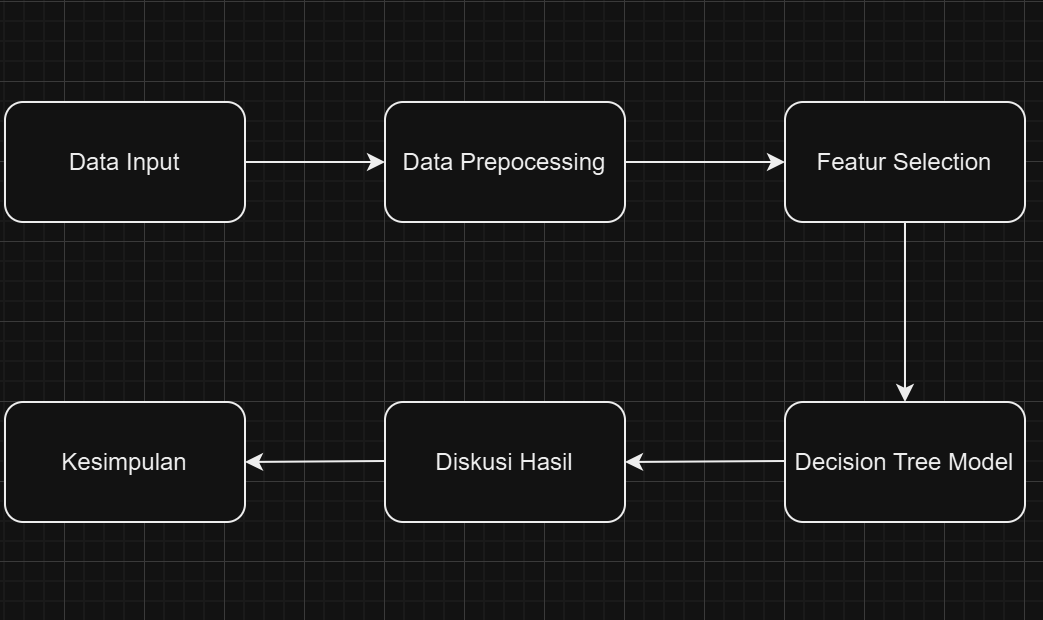

















In [1]:
from google.colab import drive # menghubungkan ke google drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/DataKasus-2')

Mounted at /content/drive


In [2]:
import pandas as pd # untuk memasukkan dataset ke dataframe
import seaborn as sns # untuk mempercantik visualisasi
import matplotlib.pyplot as plt # untuk menggambar grafik
from sklearn.model_selection import train_test_split # untuk membagi training dan testing
from sklearn.tree import DecisionTreeClassifier # kita pakai decision Tree
import numpy as np # digunakan untuk operasi matematika
from sklearn.pipeline import Pipeline #digunakan untuk mencegah nilai nya bocor
from sklearn.model_selection import GridSearchCV #digunakan untuk mendapatkan parameter optimal
# untuk melihat score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

In [3]:
# settings to display all columns
pd.set_option("display.max_columns", None)

In [4]:
dataset =pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv', sep=',', header=None)

In [5]:
dataset.head() # cek dataset

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
2,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
3,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
4,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71


In [6]:
dataset.tail()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
6603,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6604,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6605,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6606,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6607,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [7]:
dataset.info() # untuk mengetahui apakah ada yg belum angka atau tidak

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6608 non-null   object
 1   1       6608 non-null   object
 2   2       6608 non-null   object
 3   3       6608 non-null   object
 4   4       6608 non-null   object
 5   5       6608 non-null   object
 6   6       6608 non-null   object
 7   7       6608 non-null   object
 8   8       6608 non-null   object
 9   9       6608 non-null   object
 10  10      6608 non-null   object
 11  11      6530 non-null   object
 12  12      6608 non-null   object
 13  13      6608 non-null   object
 14  14      6608 non-null   object
 15  15      6608 non-null   object
 16  16      6518 non-null   object
 17  17      6541 non-null   object
 18  18      6608 non-null   object
 19  19      6608 non-null   object
dtypes: object(20)
memory usage: 1.0+ MB


# cek data kosong

In [8]:
dataset.replace("?", np.nan, inplace= True)

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6608 non-null   object
 1   1       6608 non-null   object
 2   2       6608 non-null   object
 3   3       6608 non-null   object
 4   4       6608 non-null   object
 5   5       6608 non-null   object
 6   6       6608 non-null   object
 7   7       6608 non-null   object
 8   8       6608 non-null   object
 9   9       6608 non-null   object
 10  10      6608 non-null   object
 11  11      6530 non-null   object
 12  12      6608 non-null   object
 13  13      6608 non-null   object
 14  14      6608 non-null   object
 15  15      6608 non-null   object
 16  16      6518 non-null   object
 17  17      6541 non-null   object
 18  18      6608 non-null   object
 19  19      6608 non-null   object
dtypes: object(20)
memory usage: 1.0+ MB


In [10]:
dataset.loc[:,list(dataset.loc[:,dataset.isnull().any()].columns)].isnull().sum()/(len(dataset))*100

,0
11,1.180387
16,1.361985
17,1.013923


# cek data duplikat

In [11]:
dataset = dataset.drop_duplicates()

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6608 non-null   object
 1   1       6608 non-null   object
 2   2       6608 non-null   object
 3   3       6608 non-null   object
 4   4       6608 non-null   object
 5   5       6608 non-null   object
 6   6       6608 non-null   object
 7   7       6608 non-null   object
 8   8       6608 non-null   object
 9   9       6608 non-null   object
 10  10      6608 non-null   object
 11  11      6530 non-null   object
 12  12      6608 non-null   object
 13  13      6608 non-null   object
 14  14      6608 non-null   object
 15  15      6608 non-null   object
 16  16      6518 non-null   object
 17  17      6541 non-null   object
 18  18      6608 non-null   object
 19  19      6608 non-null   object
dtypes: object(20)
memory usage: 1.0+ MB


# cek data konstan

In [13]:
dataset = dataset.loc[:,dataset.apply(pd.Series.nunique) != 1]

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6608 non-null   object
 1   1       6608 non-null   object
 2   2       6608 non-null   object
 3   3       6608 non-null   object
 4   4       6608 non-null   object
 5   5       6608 non-null   object
 6   6       6608 non-null   object
 7   7       6608 non-null   object
 8   8       6608 non-null   object
 9   9       6608 non-null   object
 10  10      6608 non-null   object
 11  11      6530 non-null   object
 12  12      6608 non-null   object
 13  13      6608 non-null   object
 14  14      6608 non-null   object
 15  15      6608 non-null   object
 16  16      6518 non-null   object
 17  17      6541 non-null   object
 18  18      6608 non-null   object
 19  19      6608 non-null   object
dtypes: object(20)
memory usage: 1.0+ MB


# visualisasi

In [15]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv')


In [16]:
df = df.drop(columns=['CategoricalColumn1', 'CategoricalColumn2'], errors='ignore')  # Menggunakan 'ignore' agar tidak error jika kolom tidak ada

In [17]:
# Menghapus kolom kategori jika ada
if 'PerformanceLevel' in df.columns:
    df['PerformanceLevel'] = df['PerformanceLevel'].map({'Low': 1, 'Medium': 2, 'High': 3})

In [18]:
# Membuat DataFrame hanya dengan kolom numerik
numeric_df = df.select_dtypes(include=[float, int])

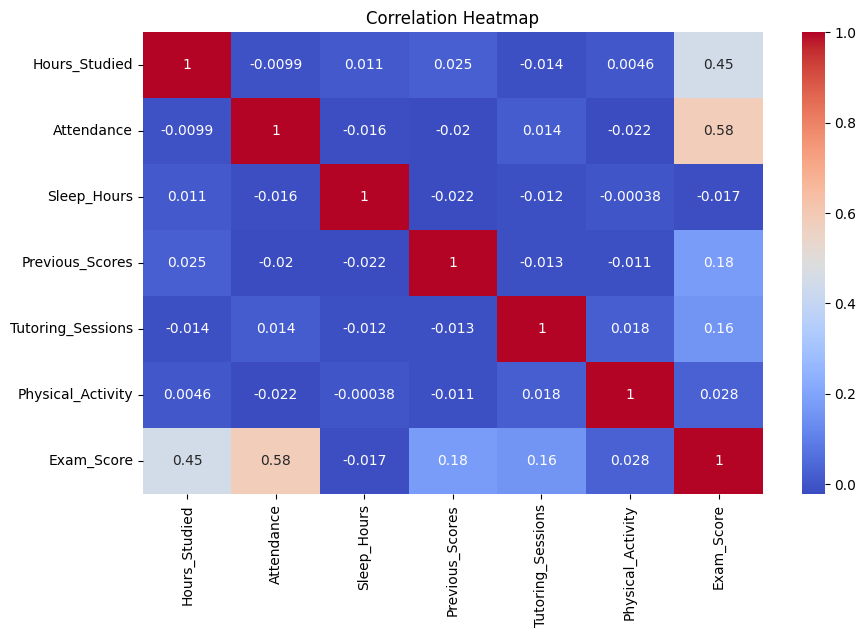

In [37]:
# Membuat heatmap korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# Memilih kolom numerik untuk analisis korelasi
numerical_columns = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Exam_Score']
numerical_data = df[numerical_columns]

In [24]:
# Menghitung matriks korelasi
correlation_matrix = numerical_data.corr()

In [25]:
# Menampilkan matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
                 Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  \
Hours_Studied         1.000000   -0.009908     0.010977         0.024846   
Attendance           -0.009908    1.000000    -0.015918        -0.020186   
Sleep_Hours           0.010977   -0.015918     1.000000        -0.021750   
Previous_Scores       0.024846   -0.020186    -0.021750         1.000000   
Exam_Score            0.445455    0.581072    -0.017022         0.175079   

                 Exam_Score  
Hours_Studied      0.445455  
Attendance         0.581072  
Sleep_Hours       -0.017022  
Previous_Scores    0.175079  
Exam_Score         1.000000  


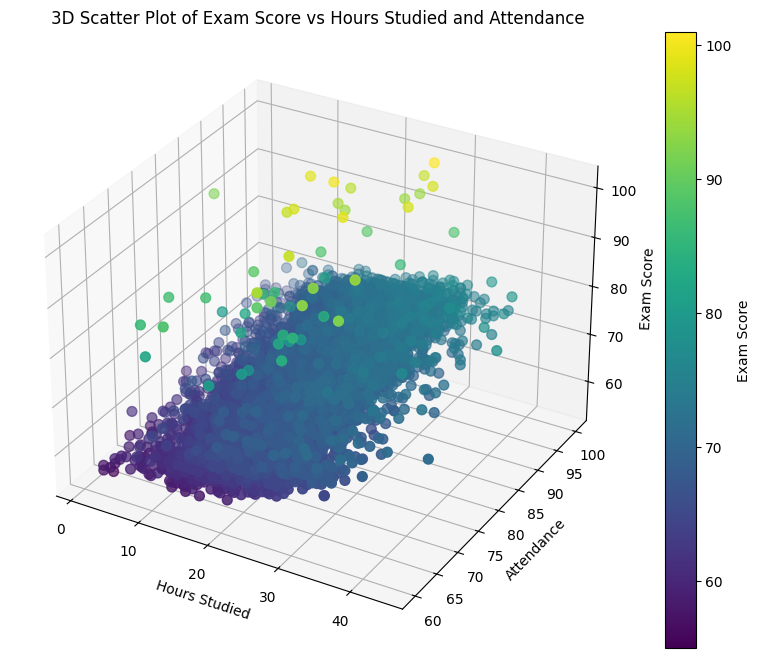

In [28]:
# Plot 3D untuk hubungan beberapa variabel
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Mendefinisikan variabel untuk plot
x = numerical_data['Hours_Studied']
y = numerical_data['Attendance']
z = numerical_data['Exam_Score']

# Membuat scatter plot 3D
scatter = ax.scatter(x, y, z, c=z, cmap='viridis', s=50)
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Attendance')
ax.set_zlabel('Exam Score')
plt.title('3D Scatter Plot of Exam Score vs Hours Studied and Attendance')
plt.colorbar(scatter, ax=ax, label='Exam Score')
plt.show()

In [ ]:
from google.colab import drive # menghubungkan ke google drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/Colab Notebooks/DataKasus-2')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Langkah 1: Import library yang dibutuhkan
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan

df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv')


In [ ]:
print("Kolom dalam dataset:")
print(df.columns)
print("\nTipe data dalam dataset:")
print(df.dtypes)

Kolom dalam dataset:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Tipe data dalam dataset:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Infl

In [ ]:
# Langkah 4: Memilih kolom yang akan digunakan untuk fungsi Hopkins
# Asumsi kolom yang digunakan hanya yang bertipe numerik
numeric_cols = df.select_dtypes(include=[np.number])

In [ ]:
# Langkah 5: Definisikan fungsi Hopkins
def hopkins(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)  # Mengambil 10% dari total data
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)

    rand_X = sample(range(0, n), m)

    ujd = []
    wjd = []
    for j in range(m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X, axis=0), np.amax(X, axis=0), d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])

    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0  # Indentasi diperbaiki di sini

    return H

In [ ]:
# Langkah 6: Menghitung nilai Hopkins untuk dataset
H_value = hopkins(numeric_cols)
print("\nNilai Hopkins:", H_value)


Nilai Hopkins: 0.7909115210226819


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv')


In [ ]:
scaler = StandardScaler()
scaled_ds = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Pastikan hanya kolom numerik yang dinormalisasi

In [ ]:
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=["PC1", "PC2", "PC3"])

In [ ]:
# Menampilkan deskripsi dari DataFrame PCA
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,6607.0,-6.667724e-17,1.328650,-4.343076,-0.928327,-0.025497,0.893399,8.096696
PC2,6607.0,-2.043335e-17,1.024685,-3.309751,-0.690853,0.014945,0.694568,3.081882
PC3,6607.0,-1.720703e-17,1.010907,-3.595481,-0.676890,-0.007869,0.678601,3.553676


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv')


In [ ]:
X = df.drop(columns=["Exam_Score"])
y = df["Exam_Score"]

In [ ]:
X_encoded = X.apply(lambda col: LabelEncoder().fit_transform(col) if col.dtype == 'object' else col)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors here
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.2004538577912254


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DataKasus-2/StudentPerformanceFactors.csv')


In [ ]:
X = df.iloc[:, :-1]  # Features
y = df.iloc[:, -1]   # Target variable


In [ ]:
X = pd.get_dummies(X)  # One-hot encoding for features
y = LabelEncoder().fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = nb_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.0832072617246596
Precision: 0.1871644581169636
Recall: 0.0832072617246596
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)


In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.20070600100857286
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.14      0.20      0.17         5
           4       0.25      0.11      0.15         9
           5       0.13      0.14      0.14        21
           6       0.20      0.24      0.22        42
           7       0.17      0.20      0.19        80
           8       0.19      0.17      0.18       111
           9       0.17      0.16      0.16       152
          10       0.27      0.24      0.26       227
          11       0.18      0.18      0.18       227
          12       0.19      0.24      0.21       202
          13       0.21      0.20      0.20       230
          14       0.24      0.26      0.25       176
          15       0.19      0.18      0.18       164
          16       0.21      0.21      0.21       123
          17       0.24    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

#####**DISKUSI HASIL DAN KESIMPULAN**
#####**Diskusi Hasil**
#####Dari hasil analisis, beberapa faktor utama yang ditemukan berpengaruh signifikan meliputi jumlah jam belajar, tingkat kehadiran di kelas, motivasi belajar, dan keterlibatan orang tua. Selain itu, faktor-faktor seperti partisipasi dalam kegiatan ekstrakurikuler, jumlah jam tidur, dan kualitas pengajaran juga memberikan kontribusi terhadap hasil akademik mahasiswa.

#####**Kesimpulan**
#####Model Decision Tree Classifier yang digunakan berhasil mengidentifikasi faktor-faktor ini sebagai prediktor utama kinerja akademik. Selain itu, partisipasi dalam kegiatan ekstrakurikuler, jumlah jam tidur, dan kualitas pengajaran juga berkontribusi terhadap hasil akademik. Evaluasi model menunjukkan performa yang memadai dalam memprediksi kinerja mahasiswa, yang diperkuat melalui optimasi parameter. Kesimpulan dari penelitian ini menegaskan pentingnya peran institusi pendidikan dalam meningkatkan faktor-faktor tersebut, serta perlunya kolaborasi dengan keluarga untuk mendukung prestasi akademik mahasiswa. Dengan memahami dan mengintervensi faktor-faktor ini, institusi pendidikan dapat lebih efektif dalam meningkatkan kinerja akademik secara keseluruhan.






